In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [28]:
def parse_log_file(filepath):
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return pd.DataFrame()
        
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = [p.strip() for p in line.split('|')]
            if len(parts) < 8:
                continue
            
            try:
                model = parts[0].split(':')[1].strip().lower()
                hidden = int(parts[1].split(':')[1].strip())
                seq = int(parts[3].split(':')[1].strip())
                
                # Time Parsing (handles with or without '+-')
                time_part = parts[6].split(':')[1].strip().replace('s', '')
                if '+-' in time_part:
                    time_mean = float(time_part.split('+-')[0].strip())
                    time_std = float(time_part.split('+-')[1].strip())
                else:
                    time_mean = float(time_part)
                    time_std = 0.0
                
                # VRAM Parsing (handles with or without '+-')
                vram_part = parts[7].split(':')[1].strip().replace('MB', '')
                if '+-' in vram_part:
                    vram_mean = float(vram_part.split('+-')[0].strip())
                    vram_std = float(vram_part.split('+-')[1].strip())
                else:
                    vram_mean = float(vram_part)
                    vram_std = 0.0
                
                data.append({
                    'Model': model,
                    'Hidden': hidden,
                    'Seq': seq,
                    'Time': time_mean,
                    'Time_std': time_std,
                    'VRAM': vram_mean,
                    'VRAM_std': vram_std
                })
            except Exception as e:
                print(f"Error parsing line: {line}\nException: {e}")
                continue
                
    return pd.DataFrame(data)


def plot_benchmark(hidden_size, mode, metric="time"):
    mode = mode.lower()
    metric = metric.lower()
    
    # Mode selection
    if mode == "train":
        filepath = "./train_time.txt"
        mode_title = "Train"
    elif mode == "rollout":
        filepath = "./rollout_time.txt"
        mode_title = "Rollout"
    else:
        raise ValueError("Mode must be 'train' or 'rollout'")
        
    df = parse_log_file(filepath)
    if df.empty:
        return
        
    df_filtered = df[df['Hidden'] == hidden_size].copy()
    if df_filtered.empty:
        print(f"No data found for hidden size '{hidden_size}' in {filepath}")
        return
        
    plt.figure(figsize=(10, 6))
    
    # Metric selection
    if metric == "time":
        y_col, y_err_col = 'Time', 'Time_std'
        y_label = "Time (seconds)"
        title = f"Hidden Size {hidden_size}: Max Seq Length vs {mode_title} Time"
    elif metric == "vram":
        y_col, y_err_col = 'VRAM', 'VRAM_std'
        y_label = "Peak VRAM (MB)"
        title = f"Hidden Size {hidden_size}: Max Seq Length vs {mode_title} Peak VRAM"
    else:
        raise ValueError("Metric must be 'time' or 'vram'")
        
    models = sorted(df_filtered['Model'].unique())
    
    for m in models:
        subset = df_filtered[df_filtered['Model'] == m].sort_values(by='Seq')
        
        # Plot mean line
        line = plt.plot(subset['Seq'], subset[y_col], marker='o', linewidth=2, label=f'Model: {m.upper()}')
        color = line[0].get_color() # Get line color to match the shaded region
        
        # Plot standard deviation as shaded region
        plt.fill_between(subset['Seq'], 
                         subset[y_col] - subset[y_err_col], 
                         subset[y_col] + subset[y_err_col], 
                         color=color, alpha=0.2) # alpha controls transparency
        
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Max Sequence Length", fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title="Architecture", loc='upper left')
    plt.tight_layout()
    plt.show()


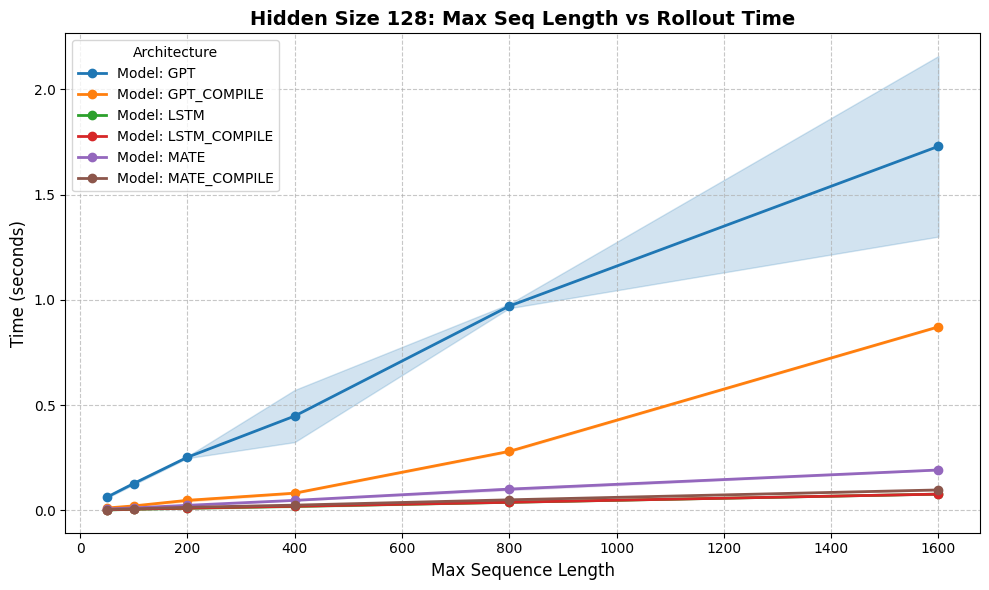

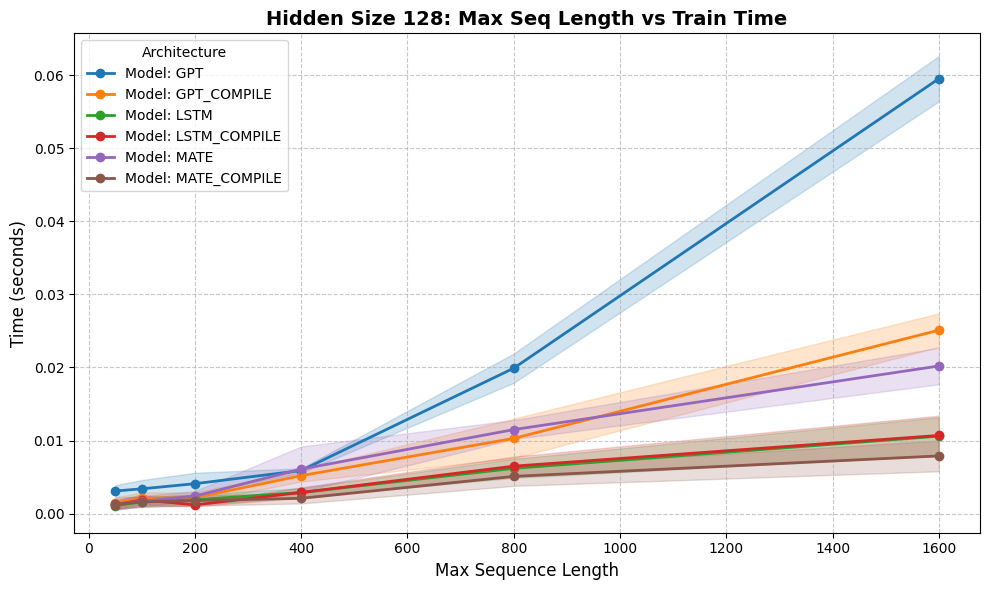

In [ ]:
# Plot Inference Time comparing models at hidden_size=256
plot_benchmark(hidden_size=256, mode="rollout", metric="time")

# Plot Backprop Time comparing models at hidden_size=256
plot_benchmark(hidden_size=256, mode="train", metric="time")

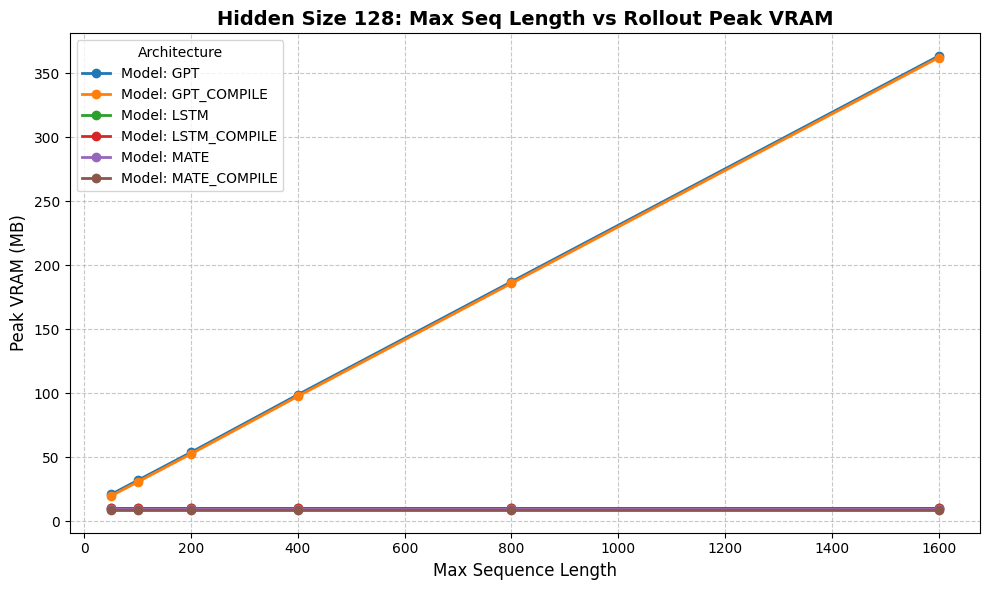

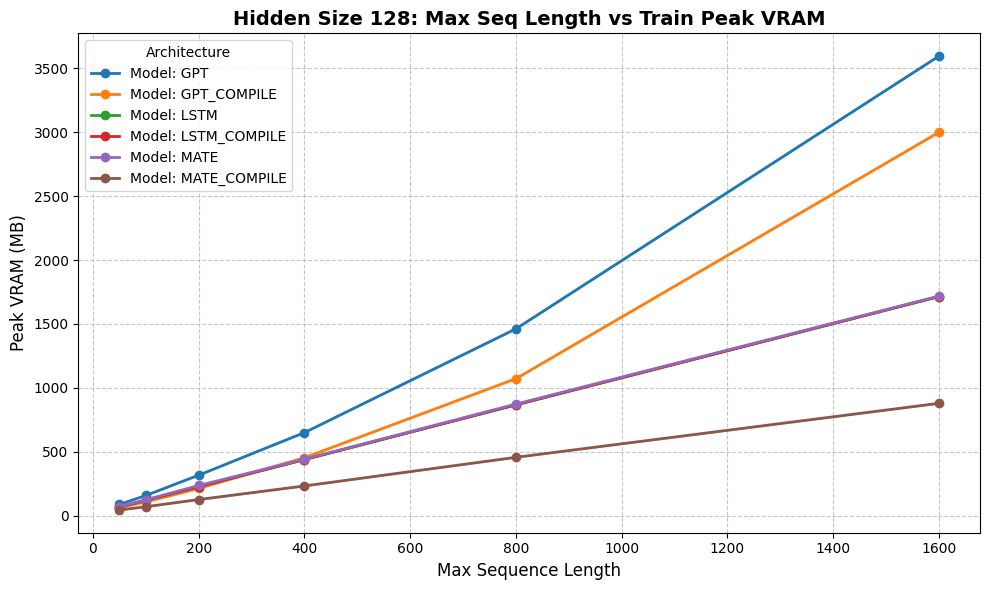

In [ ]:
# Plot Peak VRAM during Inference comparing models at hidden_size=256
plot_benchmark(hidden_size=256, mode="rollout", metric="vram")

# Plot Peak VRAM during Backprop comparing models at hidden_size=256
plot_benchmark(hidden_size=256, mode="train", metric="vram")